# Zambia FRA Maize Floor Price -Predicting the 2026 Announcement

**Author:** Boldwin Mweemba <br>
**Role:** Data & Financial Analyst - Lusaka, Zambia <br>
**Date:** June 2026 <br>


A data-driven look at what determines the Food Reserve Agency's annual maize
floor price, and a model that predicts the 2026 figure ahead of the official
announcement. Built with Python (pandas, scikit-learn, matplotlib), drawing on
live World Bank and FRED data alongside verified Zambian sources.



---

🔗 [LinkedIn](https://www.linkedin.com/in/boldwin-mweemba) 

## Exploratory Data Analysis

In [1]:
# --- Setup -------------------------------------------------------------
%matplotlib inline
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["figure.dpi"] = 110

ACCENT, RED, GREY = "#1f77b4", "#d62728", "#888888"
print("Libraries loaded.")

Libraries loaded.


##  The data

The dataset is built by a single loader cell that pulls **live data where a
reliable API exists and falls back to embedded values everywhere else**, so the
notebook always runs even offline:

- **Live - World Bank API:** inflation (`FP.CPI.TOTL.ZG`) and the kwacha/USD
  exchange rate (`PA.NUS.FCRF`), covering 2002–2024.
- **Live - FRED API:** the global maize price (`PMAIZMTUSDA`, IMF source),
  covering 2002–2025.
- **Embedded (no usable API):** the FRA floor price (announced by press release),
  the maize harvest (ZamStats), fertiliser (World Bank Pink Sheet), and the
  2025–2026 macro values the World Bank hasn't published yet.

All prices are in today's rebased kwacha (pre-2013 figures divided by 1000). The
loader prints a provenance line per column so it's always clear which values are
live and which are embedded.

In [2]:
# =============================================================================
#  DATA LOADER — live where an API exists, embedded otherwise
#    LIVE : inflation + exchange rate (World Bank), global maize (FRED)
#    EMBEDDED : FRA price, maize harvest, fertiliser, and 2025/26 macro gaps
# =============================================================================
import io
import requests
import pandas as pd

#  Embedded baseline (every column; the fallback for anything not live) ---
DATA = """year,fra_price,cpi_inflation_avg,zmw_usd_avg,maize_harvest_mt,global_maize_usd_mt,fertiliser_dap_usd_mt
2002,40,22.23,4.40,602000,99.3,168
2003,30,21.40,4.73,1158000,105.3,188
2004,36,17.97,4.78,1214000,111.8,222
2005,36,18.32,4.46,866000,98.7,247
2006,38,9.02,3.60,1424000,121.9,261
2007,38,10.66,4.00,1366000,163.7,433
2008,55,12.45,3.75,1211000,223.1,967
2009,65,13.40,5.05,1890000,165.5,323
2010,65,8.50,4.80,2800000,185.9,501
2011,65,6.43,4.86,3020000,291.7,619
2012,65,6.58,5.14,2852000,298.4,540
2013,65,6.98,5.40,2533000,259.4,445
2014,70,7.81,6.15,3350000,192.9,472
2015,75,10.11,8.63,2618000,169.8,459
2016,85,17.87,10.31,2873000,159.2,342
2017,60,6.58,9.52,2900000,154.5,344
2018,70,7.49,10.46,2395000,164.4,395
2019,110,9.15,12.89,2004000,170.1,306
2020,110,15.73,18.30,3387000,165.5,312
2021,150,22.02,20.02,3600000,259.5,601
2022,180,10.99,16.93,2700000,318.8,772
2023,280,10.88,20.17,3200000,252.7,537
2024,330,14.99,25.80,1511143,190.6,480
2025,340,14.99,27.00,3655646,195.0,600
2026,,14.99,28.00,4937605,195.0,600"""

df = pd.read_csv(io.StringIO(DATA))



In [3]:
#  Fetchers -------------------------------------------------------------
def fetch_wb(indicator):
    """{year: value} for a World Bank indicator (Zambia); {} if unreachable."""
    try:
        url = f"https://api.worldbank.org/v2/country/ZMB/indicator/{indicator}"
        r = requests.get(url, params={"format": "json", "date": "2002:2026",
                                      "per_page": 100}, timeout=30)
        r.raise_for_status()
        payload = r.json()
        if len(payload) < 2 or payload[1] is None:
            return {}
        return {int(d["date"]): round(float(d["value"]), 2)
                for d in payload[1] if d["value"] is not None}
    except Exception as e:
        print(f"  [info] World Bank {indicator} unreachable ({e}); using embedded.")
        return {}

def fetch_fred_annual(series_id):
    """{year: value} for a FRED annual series (keyless CSV); {} if unreachable."""
    try:
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
        raw = pd.read_csv(url)
        dc, vc = raw.columns[0], raw.columns[1]
        raw["year"] = pd.to_datetime(raw[dc]).dt.year
        raw[vc] = pd.to_numeric(raw[vc], errors="coerce")
        return {int(y): round(float(v), 1)
                for y, v in zip(raw["year"], raw[vc]) if pd.notna(v)}
    except Exception as e:
        print(f"  [info] FRED {series_id} unreachable ({e}); using embedded.")
        return {}

#  Live sources: column -> (label, fetcher) -----------------------------
LIVE_SOURCES = {
    "cpi_inflation_avg":   ("World Bank", lambda: fetch_wb("FP.CPI.TOTL.ZG")),
    "zmw_usd_avg":         ("World Bank", lambda: fetch_wb("PA.NUS.FCRF")),
    "global_maize_usd_mt": ("FRED",       lambda: fetch_fred_annual("PMAIZMTUSDA")),
}
EMBEDDED_ONLY = {
    "fra_price":             "press/academic (no API)",
    "maize_harvest_mt":      "ZamStats (no reliable API)",
    "fertiliser_dap_usd_mt": "World Bank Pink Sheet (no clean API)",
}

#  Apply live values over the embedded baseline -------------------------
provenance = {}
for col, (src, fetch) in LIVE_SOURCES.items():
    live = fetch()
    yrs = []
    for yr, val in live.items():
        if yr in df["year"].values:
            df.loc[df["year"] == yr, col] = val
            yrs.append(yr)
    provenance[col] = (src, sorted(yrs))

#  Provenance report ----------------------------------------------------
print("Data provenance:")
for col, (src, yrs) in provenance.items():
    if yrs:
        missing = [int(y) for y in df["year"] if y not in yrs]
        print(f"  {col:22s}: {src} {min(yrs)}-{max(yrs)} | embedded {missing}")
    else:
        print(f"  {col:22s}: embedded ({src} unreachable)")
for col, why in EMBEDDED_ONLY.items():
    print(f"  {col:22s}: embedded — {why}")

#  Derived columns + known-price history frame --------------------------
# Named constants used by the plots downstream
ELECTION_YEARS = {2006, 2011, 2016, 2021, 2026}
LOW_CONF = {2010, 2011, 2012, 2014, 2015}
df["election_year"] = df["year"].isin({2006, 2011, 2016, 2021, 2026}).astype(int)
df["prev_price"] = df["fra_price"].shift(1)
df["maize_harvest_m"] = df["maize_harvest_mt"] / 1e6
hist = df[df["fra_price"].notna()].copy()
df

Data provenance:
  cpi_inflation_avg     : World Bank 2002-2024 | embedded [2025, 2026]
  zmw_usd_avg           : World Bank 2002-2024 | embedded [2025, 2026]
  global_maize_usd_mt   : FRED 2002-2025 | embedded [2026]
  fra_price             : embedded — press/academic (no API)
  maize_harvest_mt      : embedded — ZamStats (no reliable API)
  fertiliser_dap_usd_mt : embedded — World Bank Pink Sheet (no clean API)


,year,fra_price,cpi_inflation_avg,zmw_usd_avg,maize_harvest_mt,global_maize_usd_mt,fertiliser_dap_usd_mt,election_year,prev_price,maize_harvest_m
0,2002,40.0,22.23,4.40,602000,99.3,168,0,NaN,0.602000
1,2003,30.0,21.40,4.73,1158000,105.2,188,0,40.0,1.158000
2,2004,36.0,17.97,4.78,1214000,111.9,222,0,30.0,1.214000
3,2005,36.0,18.32,4.46,866000,98.5,247,0,36.0,0.866000
4,2006,38.0,9.02,3.60,1424000,121.6,261,1,36.0,1.424000
5,2007,38.0,10.66,4.00,1366000,163.6,433,0,38.0,1.366000
6,2008,55.0,12.45,3.75,1211000,223.4,967,0,38.0,1.211000
7,2009,65.0,13.40,5.04,1890000,165.6,323,0,55.0,1.890000
8,2010,65.0,8.50,4.80,2800000,186.0,501,0,65.0,2.800000
9,2011,65.0,6.43,4.86,3020000,291.9,619,1,65.0,3.020000


In [4]:
# Quick statistical summary of the known-price years
hist.describe().round(2)

,year,fra_price,cpi_inflation_avg,zmw_usd_avg,maize_harvest_mt,global_maize_usd_mt,fertiliser_dap_usd_mt,election_year,prev_price,maize_harvest_m
count,24.00,24.00,24.00,24.00,24.00,24.00,24.00,24.00,23.00,24.00
mean,2013.50,102.42,12.61,10.07,2297074.54,188.50,438.92,0.17,92.09,2.30
std,7.07,90.56,5.19,7.38,928633.76,63.71,188.92,0.38,76.79,0.93
min,2002.00,30.00,6.43,3.60,602000.00,98.50,168.00,0.00,30.00,0.60
25%,2007.75,51.25,8.33,4.77,1409500.00,158.05,310.50,0.00,47.50,1.41
50%,2013.50,65.00,10.94,5.78,2575500.00,170.00,439.00,0.00,65.00,2.58
75%,2019.25,110.00,16.26,13.90,2930000.00,230.42,537.75,0.00,97.50,2.93
max,2025.00,340.00,22.23,27.00,3655646.00,318.40,967.00,1.00,330.00,3.66


## 1. The target - the FRA price over time

Before hunting for what drives the FRA price, we need to understand the shape of
the thing we're predicting. The Food Reserve Agency sets a single floor price
(Kwacha per 50 kg bag) once a year, so our target is a short annual series with
one observation per season from 2002 to 2025.

Three things are worth checking up front:

- **The trend** - how the price has moved over two decades (and where the
  election years and low-confidence data points sit).
- **The year-on-year changes** - how often, and by how much, the price actually
  moves.
- **The distribution** - what range of values the price has historically taken.

The plots below answer each in turn. The headline to watch for: the FRA price is
**sticky and almost entirely upward** - it is rarely cut, only held or raised.
That single property is the strongest clue in the whole analysis, because it
means *last year's price* will carry most of the predictive weight.

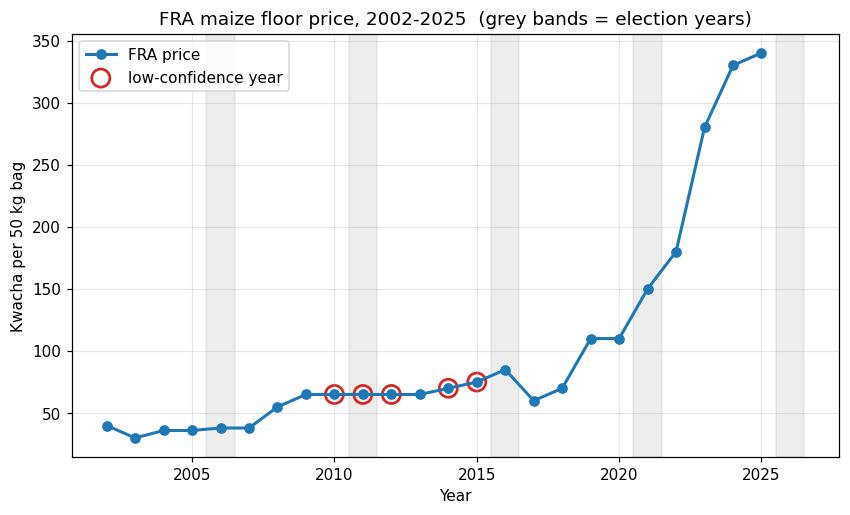

In [5]:
#  FRA price over time, with election years shaded
fig, ax = plt.subplots()
ax.plot(hist["year"], hist["fra_price"], "o-", color=ACCENT, lw=2, label="FRA price")
for yr in ELECTION_YEARS:
    ax.axvspan(yr-0.5, yr+0.5, color=GREY, alpha=0.15)
# highlight low-confidence points
low = hist[hist["year"].isin(LOW_CONF)]
ax.scatter(low["year"], low["fra_price"], facecolors="none", edgecolors=RED,
           s=140, lw=1.8, label="low-confidence year")
ax.set_title("FRA maize floor price, 2002-2025  (grey bands = election years)")
ax.set_xlabel("Year"); ax.set_ylabel("Kwacha per 50 kg bag")
ax.legend()
plt.show()

The price is **sticky and almost entirely upward**. Across the full 2002-2025
series it has fallen only **twice** - in 2003 (K40 → K30) and 2017 (K85 → K60).
Every other year it was either held flat or raised. After 2018 the increases
became much steeper, taking the price from K70 to K340 by 2025.

This stickiness is the single biggest clue in the whole analysis: because the
price so rarely falls, **last year's price is a very strong predictor of this
year's** - the FRA effectively anchors on the previous figure and adjusts upward.

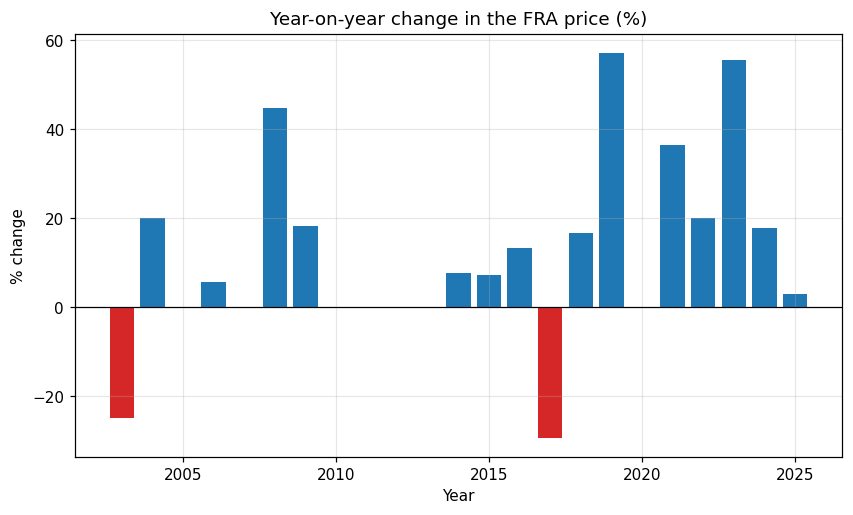

Times the price was CUT: 2 out of 23 year-on-year moves


In [6]:
#  Year-on-year % change
chg = hist.copy()
chg["yoy"] = chg["fra_price"].pct_change() * 100
fig, ax = plt.subplots()
colors = [RED if v < 0 else ACCENT for v in chg["yoy"]]
ax.bar(chg["year"], chg["yoy"], color=colors)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Year-on-year change in the FRA price (%)")
ax.set_xlabel("Year"); ax.set_ylabel("% change")
plt.show()

print("Times the price was CUT:", int((chg["yoy"] < 0).sum()),
      "out of", chg["yoy"].notna().sum(), "year-on-year moves")

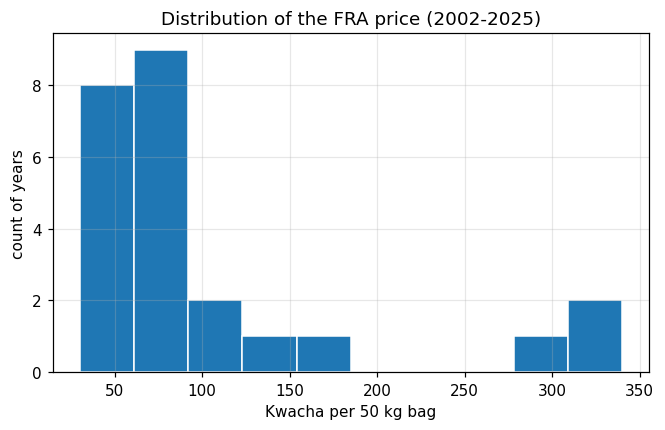

In [7]:
#  Distribution of the price
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(hist["fra_price"], bins=10, color=ACCENT, edgecolor="white")
ax.set_title("Distribution of the FRA price (2002-2025)")
ax.set_xlabel("Kwacha per 50 kg bag"); ax.set_ylabel("count of years")
plt.show()

**A few notes on the distribution:**

- The distribution is **strongly right-skewed**, not bell-shaped. Most years sit
  low and a handful of recent years sit far out to the right.
- About **17 of the 24 years fall below K90** — reflecting the long 2002–2018
  era when the price stayed in the K30–K85 band. This is the "normal" the FRA
  operated in for most of the period.
- There's a visible **gap between roughly K180 and K280** with no observations.
  That empty space is the 2023 jump (K180 → K280) — the price leapt rather than
  passing through the middle, so no year ever landed there.
- The cluster at the top (K280–K340) is just the **last three years (2023–2025)**,
  showing how recent and how sharp the escalation has been.
- **Implication for the model:** because the price isn't drawn from one stable
  distribution — the recent regime looks very different from the historical one —
  the model leans on *last year's price* (the current level) rather than treating
  every year as a draw from the same pool. It also means predicting 2026 involves
  extrapolating into the sparse high end, where we have few data points — a reason
  to treat the forecast as indicative.

## 2. The candidate drivers over time

The features we'll test: inflation, the kwacha/USD rate, the maize harvest,
the global maize price, and fertiliser cost.

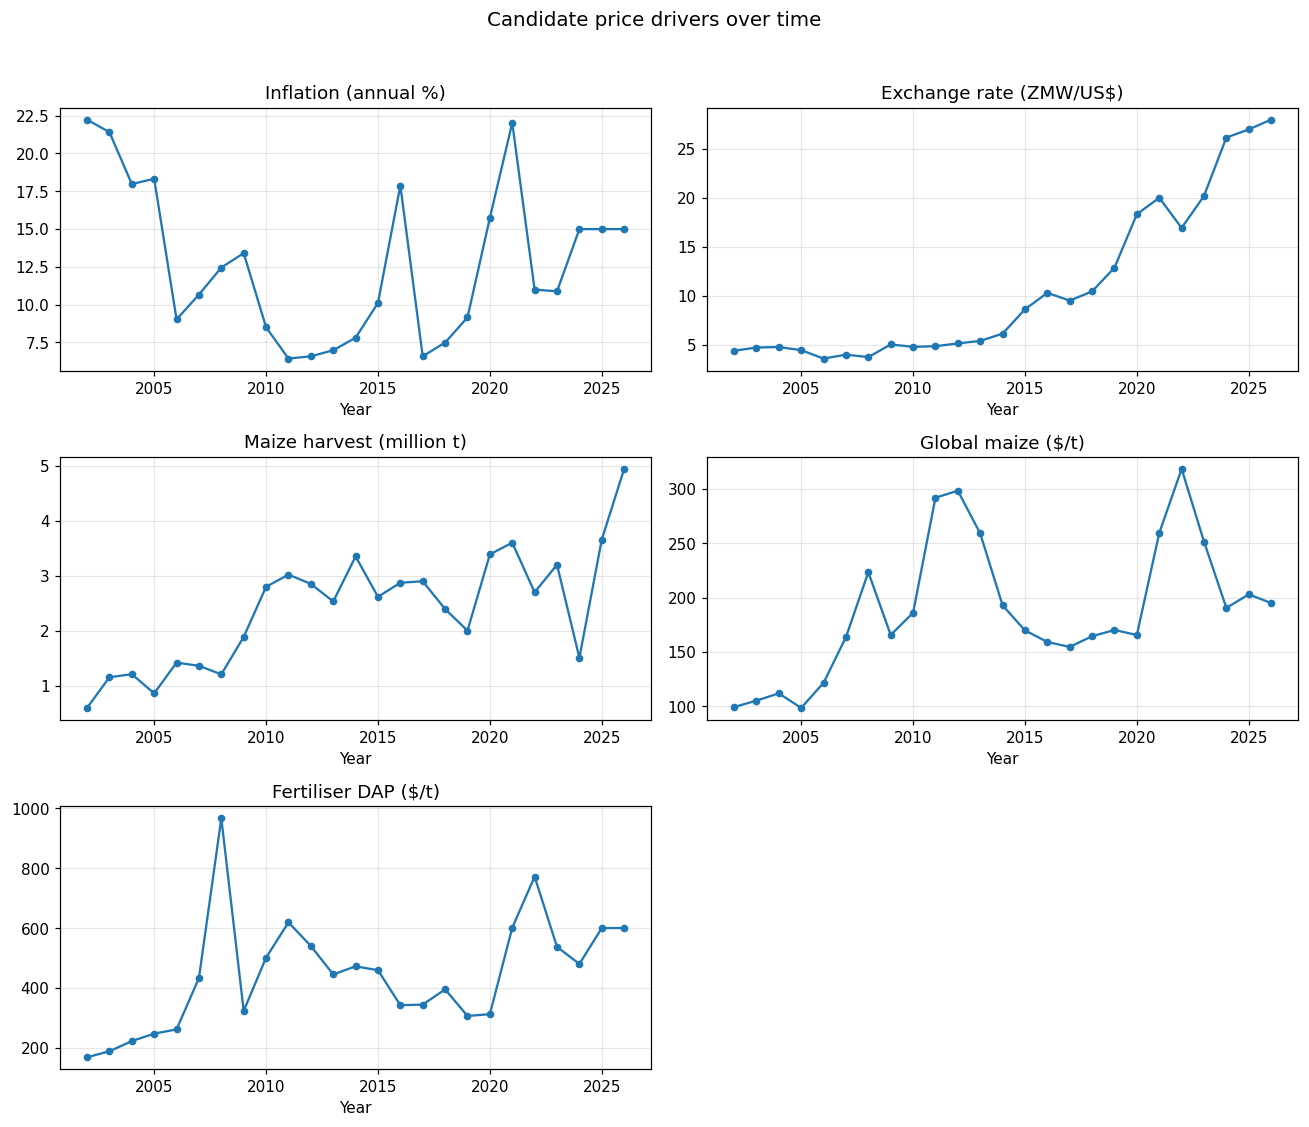

In [8]:
#  Small-multiples: each driver over time
feats = [("cpi_inflation_avg", "Inflation (annual %)"),
         ("zmw_usd_avg", "Exchange rate (ZMW/US$)"),
         ("maize_harvest_m", "Maize harvest (million t)"),
         ("global_maize_usd_mt", "Global maize ($/t)"),
         ("fertiliser_dap_usd_mt", "Fertiliser DAP ($/t)")]
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.ravel()
for ax, (col, label) in zip(axes, feats):
    ax.plot(df["year"], df[col], "o-", color=ACCENT, ms=4)
    ax.set_title(label); ax.set_xlabel("Year")
axes[-1].axis("off")   # blank the 6th panel
fig.suptitle("Candidate price drivers over time", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

**A few notes on the drivers:**

- **Exchange rate** is the standout. It's the only panel with a clean, one-way
  trend - broadly flat near K4-5/US$ until about 2014, then a steep, sustained
  depreciation to ~K28 by 2026. Because it *trends* the same way the FRA price
  does, it ends up being the strongest driver after the previous price.
- **Inflation** is volatile and mean-reverting - it swings between ~6% and ~22%
  with no lasting trend. That's exactly why it correlates weakly with the price
  *level*: a bouncing rate doesn't line up with a steadily rising price.
- **Maize harvest** is noisy with only a mild upward drift. The 2024 drought
  collapse (~1.5 M t) and the projected 2026 record (~4.9 M t) stand out, but
  there's no clean relationship with the price - consistent with its weak model
  coefficient.
- **Global maize** and **fertiliser** move together - both spike in 2008, again
  in 2011-12, and again in 2021–22. That shared commodity-cycle pattern is the
  0.78 correlation between them, and the reason adding both to the model added
  redundancy rather than information.

> **Note:** the flat segments at the right-hand end of the inflation and
> fertiliser panels (roughly 2024–2026) are embedded placeholder values, since
> the World Bank/Pink Sheet figures for those years aren't published yet. Live
> series (exchange rate, global maize) extend further.

Note the **2021 record harvest** and the **2024 drought collapse** (1.5 M t),
the steady kwacha depreciation, and the global fertiliser/maize spikes around
2008 and 2021–22.

## 3. How each driver relates to the price

Correlation first, then the scatter plots behind the correlations.

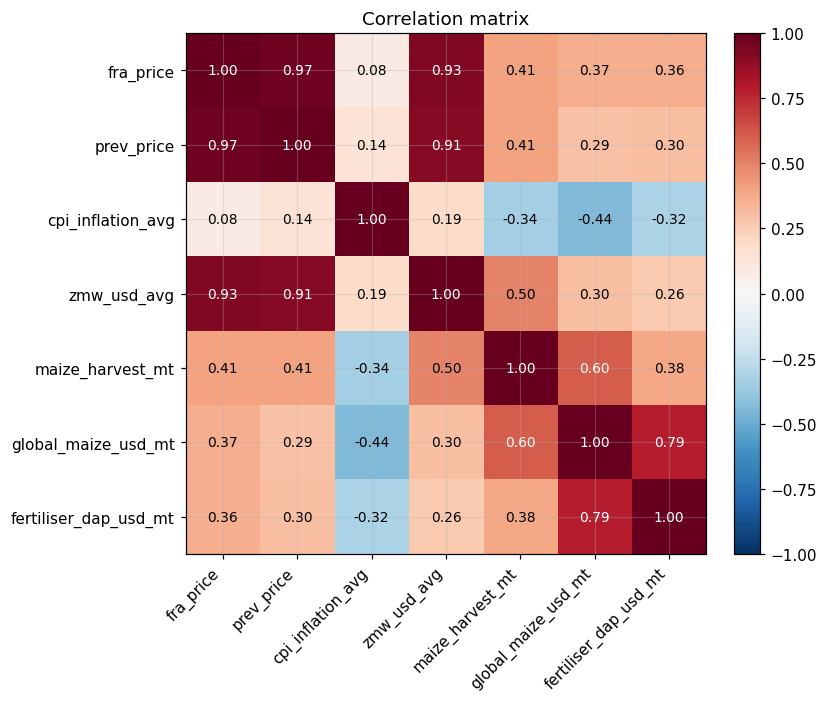

In [9]:
#  Correlation heatmap
cols = ["fra_price", "prev_price", "cpi_inflation_avg", "zmw_usd_avg",
        "maize_harvest_mt", "global_maize_usd_mt", "fertiliser_dap_usd_mt"]
corr = hist[cols].corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(cols))); ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha="right"); ax.set_yticklabels(cols)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center",
                color="white" if abs(corr.iloc[i,j])>0.5 else "black", fontsize=9)
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title("Correlation matrix")
plt.tight_layout(); plt.show()

`prev_price` and `zmw_usd_avg` are the strongest correlates of the price.
The harvest correlation is weak — exactly what we found when we corrected the
harvest data.

### Reading the correlation matrix 

The heatmap confirms the model's structure , but one cell is a trap (I think).

- **`prev_price` (0.97) and `zmw_usd_avg` (0.93)** are by far the strongest
  correlates of the FRA price. That is the model in two numbers: *last year's
  price, adjusted for the kwacha.*

- **The harvest trap.** `maize_harvest_mt` shows a **positive** correlation with
  the price (+0.41), which looks backwards , more maize "should" mean a lower
  price. This raw correlation is **spurious**: harvest and price have both
  drifted upward over two decades, so they share a time trend. Once the model
  controls for `prev_price` and the other drivers, harvest flips to a (weak)
  **negative** coefficient - the economically sensible direction. *Therefore: do
  not read causation off a correlation matrix.*

- **Multicollinearity.** `prev_price` and `zmw_usd_avg` correlate with each
  other at 0.91, so they carry overlapping information. The model can't fully
  separate their individual effects , we shouldn't over-interpret the exact
  split of their coefficients.

- **Why adding both Pink Sheet features overfit.** `global_maize_usd_mt` and
  `fertiliser_dap_usd_mt` correlate at 0.78 - they are largely the *same* global
  commodity signal. Including both adds redundancy, not information, which is why
  the cross-validation error rose.

- **The surprise.** Inflation is almost uncorrelated with the price (0.08),
  because inflation is a *rate* (bouncing 6-22%) while the price is a rising
  *level*. Inflation acts on the price mostly *indirectly*, through the exchange
  rate.

**Key point:** every modelling choice we made - leaning on `prev_price` + FX,
keeping harvest despite its weak signal, and dropping the Pink Sheet extras , is
consistent with what this matrix shows.

> **What is the "Pink Sheet"?** It's the World Bank's monthly *Commodity Markets*
> price report (nicknamed for the pink paper it was once printed on). Free and
> running since 1960, it tracks world prices for commodities such as oil, metals,
> grains, and fertilisers. Two of our features - `global_maize_usd_mt` (world
> maize price) and `fertiliser_dap_usd_mt` (DAP fertiliser price) , come from it,
> because these sit in the Pink Sheet rather than the World Bank's main data API.
> 

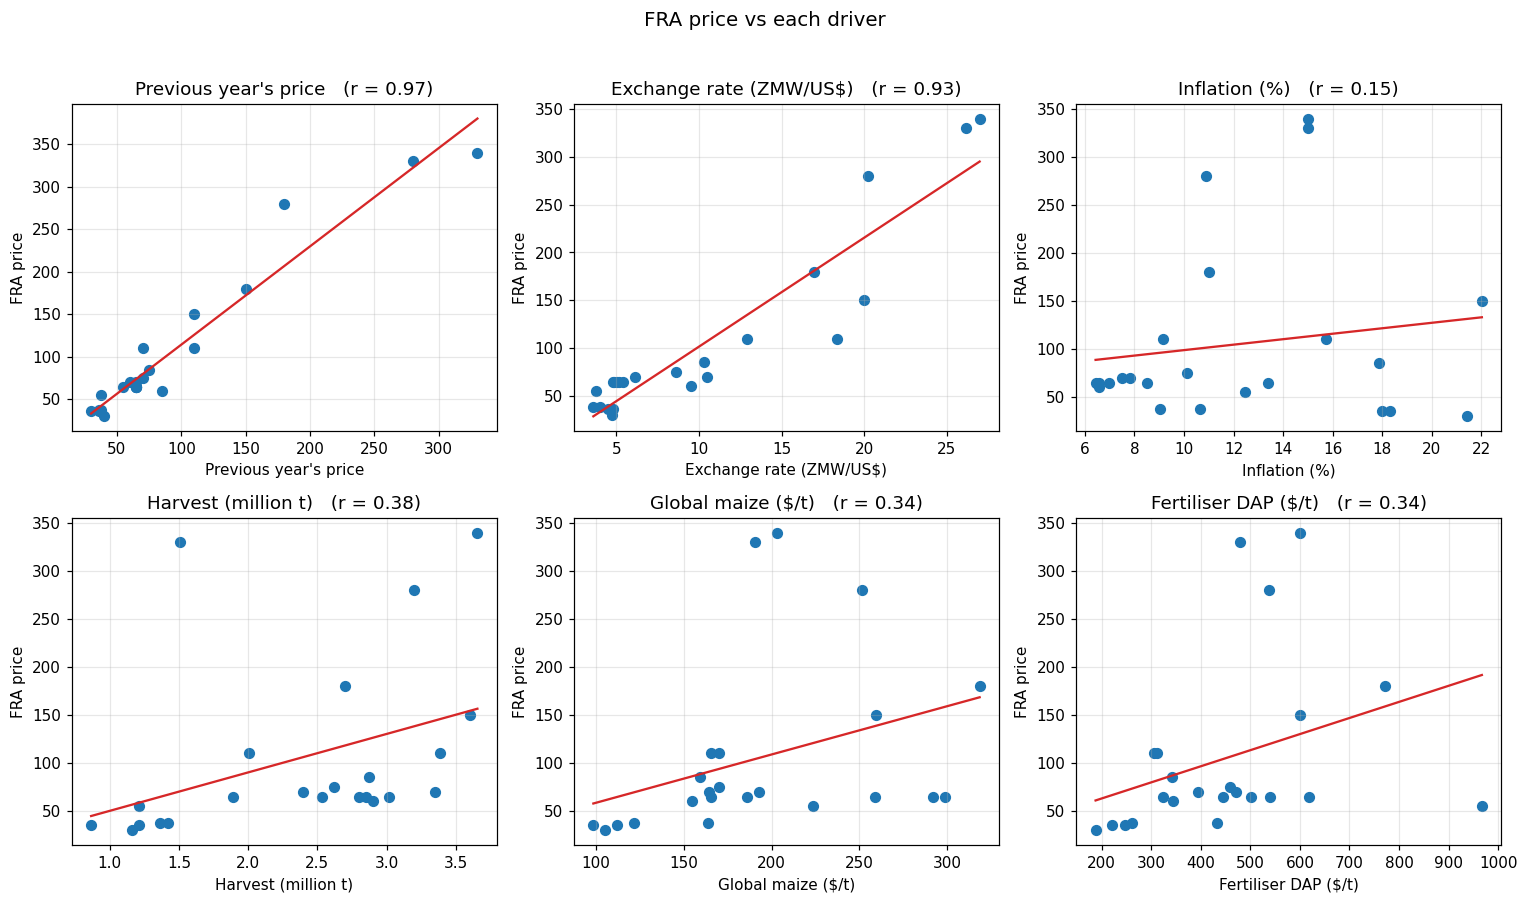

In [10]:
# Scatter of price vs the main drivers (with simple trend lines)
pairs = [("prev_price", "Previous year's price"),
         ("zmw_usd_avg", "Exchange rate (ZMW/US$)"),
         ("cpi_inflation_avg", "Inflation (%)"),
         ("maize_harvest_m", "Harvest (million t)"),
         ("global_maize_usd_mt", "Global maize ($/t)"),
         ("fertiliser_dap_usd_mt", "Fertiliser DAP ($/t)")]
d = hist.dropna(subset=["prev_price"])
fig, axes = plt.subplots(2, 3, figsize=(14, 8)); axes = axes.ravel()
for ax, (col, label) in zip(axes, pairs):
    ax.scatter(d[col], d["fra_price"], color=ACCENT, s=40)
    m, b = np.polyfit(d[col], d["fra_price"], 1)
    xs = np.linspace(d[col].min(), d[col].max(), 50)
    ax.plot(xs, m*xs + b, color=RED, lw=1.5)
    r = d[col].corr(d["fra_price"])
    ax.set_title(f"{label}   (r = {r:.2f})")
    ax.set_xlabel(label); ax.set_ylabel("FRA price")
fig.suptitle("FRA price vs each driver", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

**Notes on the scatter plots:**

- **Previous year's price (r = 0.97)** -the points hug the trend line almost
  perfectly. This is the visual proof of price stickiness: knowing last year's
  price tells you most of what you need for this year.
- **Exchange rate (r = 0.93)** - a clear, tight positive relationship. A weaker
  kwacha goes hand-in-hand with a higher floor price. Together with the previous
  price, this is what the model leans on.
- **Inflation (r = 0.15)** - essentially a flat cloud with no pattern; the trend
  line is nearly horizontal. High-price years occur at all inflation levels.
  This confirms inflation carries little direct signal for the price *level*.
- **Harvest, global maize, fertiliser (r ≈ 0.34-0.38)** - all three show weak,
  heavily scattered positive slopes. These slopes are largely **spurious**: each
  variable and the price have drifted upward over time, so they correlate without
  a real causal link. The clearest giveaways are the outliers that run against
  the trend - e.g. **2008 had the highest fertiliser price (~$967/t) but a low
  FRA price (~K55)**, and **2024 had one of the lowest harvests (1.5 M t) yet one
  of the highest prices (K330)**.

**Takeaway:** only the top-left two panels show relationships strong and clean
enough to trust. The bottom row looks related but is mostly shared time-trend -
which is exactly why those features added little to the model.

## 4. The election-year effect

Does the FRA raise the price more generously in election years? Compare the
year-on-year change in election vs non-election years.

C:\Users\BOLDWIN MWEEMBA\AppData\Local\Temp\ipykernel_6904\3579973273.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([non, elec], labels=["Non-election", "Election"])


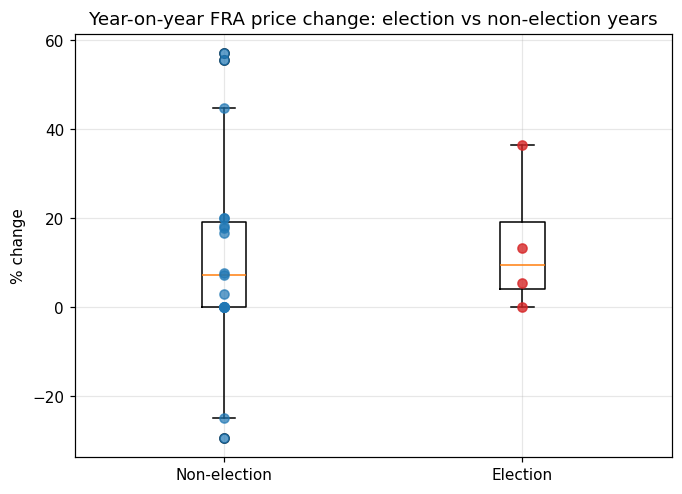

Mean YoY change  | election years:  13.8%   non-election:  11.2%


In [11]:
# 4. Election vs non-election year price changes
chg2 = hist.copy()
chg2["yoy"] = chg2["fra_price"].pct_change() * 100
chg2 = chg2.dropna(subset=["yoy"])
elec = chg2[chg2["election_year"] == 1]["yoy"]
non  = chg2[chg2["election_year"] == 0]["yoy"]

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([non, elec], labels=["Non-election", "Election"])
ax.scatter(np.ones(len(non)),  non,  color=ACCENT, alpha=0.7, zorder=3)
ax.scatter(np.ones(len(elec))*2, elec, color=RED, alpha=0.8, zorder=3)
ax.set_title("Year-on-year FRA price change: election vs non-election years")
ax.set_ylabel("% change")
plt.show()

print(f"Mean YoY change  | election years: {elec.mean():5.1f}%   "
      f"non-election: {non.mean():5.1f}%")



**A few notes on the election effect:**

- On average, the FRA price rises **13.8% in election years versus 11.2% in
  non-election years** - a modest gap of about 2.6 percentage points that leans
  in the direction of the "election generosity" idea. (The box-plot medians tell
  the same story; the means sit higher because a few large increases pull them
  up.)
- More tellingly, **election years never saw a cut** - every election-year change
  is zero or positive - while the only **two price cuts in the whole series
  (2003 and 2017) both fell in non-election years**.
- But the case is weak. The boxes **overlap heavily**, and non-election years
  actually contain the *largest* single increases (~55%), so a big rise is not
  unique to elections. Most of all, there are only **four election years** with a
  year-on-year change in the data - far too few to draw a firm conclusion.

**Take away** there's a faint tilt toward more generous, never-negative moves in
election years (13.8% vs 11.2% on average), but the sample is tiny and the spread
wide. This is exactly why the election flag carried a near-zero coefficient in
the model - we keep it for its theoretical relevance, but we don't lean on it.

### Model choice

This analysis uses **Ridge regression**  linear regression with L2
regularisation (`alpha = 1.0`), with features standardised via `StandardScaler`
and evaluated by leave-one-out cross-validation.

Ridge is chosen because the price-setting relationship is close to linear
("last year's price, adjusted for conditions"), the model stays **interpretable**
- its standardised coefficients show the direction and relative size of each
driver's effect - and the L2 penalty keeps the coefficients stable despite the
strong correlation between the previous price and the exchange rate.

**Assumptions made in choosing this model:**

- **Linearity** - each driver relates to the FRA price in an approximately
  linear way.
- **Additivity** - the drivers act independently and their effects sum; no
  interaction terms are modelled.
- **Standardised features** - variables are scaled to comparable units so the
  regularisation penalises each coefficient fairly and the coefficients can be
  read against one another.
- **Coefficient shrinkage** - the L2 penalty assumes coefficients should be
  pulled toward zero, trading a little bias for lower variance (appropriate for a
  small, correlated dataset).
- **A stable relationship over time** - the way the FRA sets the price is assumed
  to be reasonably consistent across the 2002–2026 period.
- **Observations treated as independent** in cross-validation, even though the
  series is temporally autocorrelated; the previous-year price is included
  explicitly to absorb that year-to-year dependence.

In [12]:
# --- Modelling setup ---------------------------------------------------
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error, r2_score

BASE = ["prev_price", "cpi_inflation_avg", "zmw_usd_avg",
        "maize_harvest_mt", "election_year"]
FEATURE_SETS = {
    "base (5 features)":      BASE,
    "base + fertiliser":      BASE + ["fertiliser_dap_usd_mt"],
    "base + global maize":    BASE + ["global_maize_usd_mt"],
    "base + both Pink Sheet": BASE + ["fertiliser_dap_usd_mt", "global_maize_usd_mt"],
}
train = hist.dropna(subset=["prev_price"]).copy()
y = train["fra_price"].values

def loo(features):
    X = train[features].values
    preds, actuals = [], []
    for tr, te in LeaveOneOut().split(X):
        sc = StandardScaler().fit(X[tr])
        m = Ridge(alpha=1.0).fit(sc.transform(X[tr]), y[tr])
        preds.append(m.predict(sc.transform(X[te]))[0]); actuals.append(y[te][0])
    return np.array(actuals), np.array(preds)

results = {name: loo(f) for name, f in FEATURE_SETS.items()}
summary = pd.DataFrame({
    name: {"LOO_MAE": mean_absolute_error(a, p), "R2": r2_score(a, p)}
    for name, (a, p) in results.items()}).T.round(3)
summary

,LOO_MAE,R2
base (5 features),14.542,0.931
base + fertiliser,15.248,0.932
base + global maize,15.415,0.939
base + both Pink Sheet,16.058,0.937


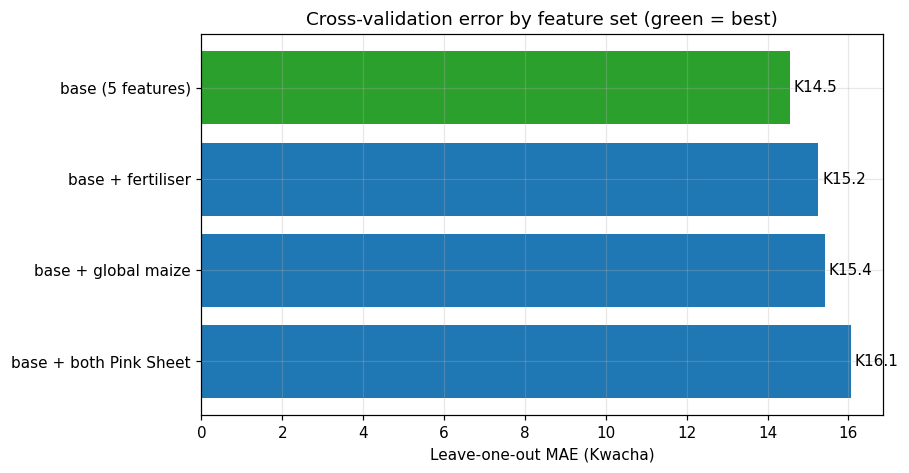

In [13]:
# 5a. Feature-set comparison (lower MAE = better)
GREEN = "#2ca02c"
fig, ax = plt.subplots(figsize=(8, 4.5))
order = summary.sort_values("LOO_MAE")
colors = [GREEN if i == 0 else ACCENT for i in range(len(order))]
ax.barh(order.index, order["LOO_MAE"], color=colors)
ax.invert_yaxis()
ax.set_title("Cross-validation error by feature set (green = best)")
ax.set_xlabel("Leave-one-out MAE (Kwacha)")
for i, v in enumerate(order["LOO_MAE"]):
    ax.text(v+0.1, i, f"K{v:.1f}", va="center")
plt.show()

**A few notes on feature selection:**

- The chart compares how well each feature set predicts a held-out year (lower
  leave-one-out MAE = better). The **base 5-feature model wins at K14.5**, and
  it's the *simplest* set - nothing extra added.
- Every addition makes the model **worse**, and steadily so: adding fertiliser
  (K15.2), then global maize (K15.4), then both (K16.1). The error rises roughly
  in step with the number of extra features.
- That monotonic climb is a textbook **small-sample overfitting** signal. With
  only ~24 annual points, each extra feature gives the model more freedom to fit
  noise, which then hurts it on the year it hasn't seen.
- It also matches the correlation evidence: fertiliser and global maize are
  largely the same commodity-cycle signal (~0.78 correlated), so they add
  redundancy rather than new information.

**Takeaway:** more features did not mean a better model here - the opposite. We
keep the parsimonious 5-feature set (previous price, exchange rate, inflation,
harvest, election year), which is both the most accurate out-of-sample.

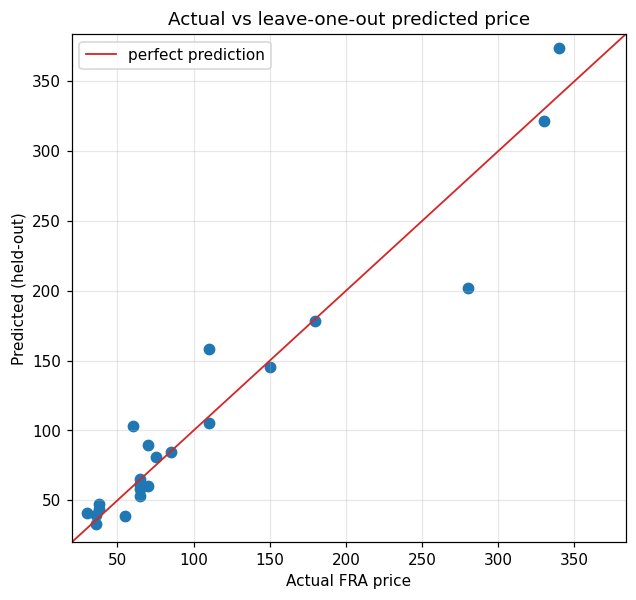

In [14]:
# 5b. Actual vs leave-one-out predicted, for the winning model
best_feats = FEATURE_SETS["base (5 features)"]
a, p = results["base (5 features)"]
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(a, p, color=ACCENT, s=45)
lims = [min(a.min(), p.min())-10, max(a.max(), p.max())+10]
ax.plot(lims, lims, color=RED, lw=1.2, label="perfect prediction")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_title("Actual vs leave-one-out predicted price")
ax.set_xlabel("Actual FRA price"); ax.set_ylabel("Predicted (held-out)")
ax.legend()
plt.show()

**A few notes on predictive accuracy:**

- Each point is a year the model **never saw during training** (leave-one-out),
  plotted against its actual price. Points near the red line are good predictions.
- Overall the model tracks the diagonal well - confirming the R² ≈ 0.93. It's
  most accurate in the **dense low range (below ~K100)**, where most years sit
  and the points hug the line tightly.
- The biggest misses are at the **policy turning points**, exactly where you'd
  expect:
  - **2017 (actual K60):** the model predicted ~K103. It couldn't foresee the
    *price cut* (K85 → K60), because the previous price pointed upward.
  - **2023 (actual K280):** the model predicted ~K202. It under-shot the sudden
    *leap* (K180 → K280) for the same reason — no prior year signalled a jump
    that large.
- The **high end (K280-K340) is sparse** and shows more scatter, consistent with
  the caveat that the recent regime has few data points to learn from.

**Takeaway:** the model captures the underlying trend well but cannot anticipate
**sudden discretionary moves** -a one-off cut or an outsized jump. That's a
direct consequence of the FRA price being a political decision rather than a
purely mechanical one, and it's the main reason the 2026 forecast should be read
as indicative, not exact.

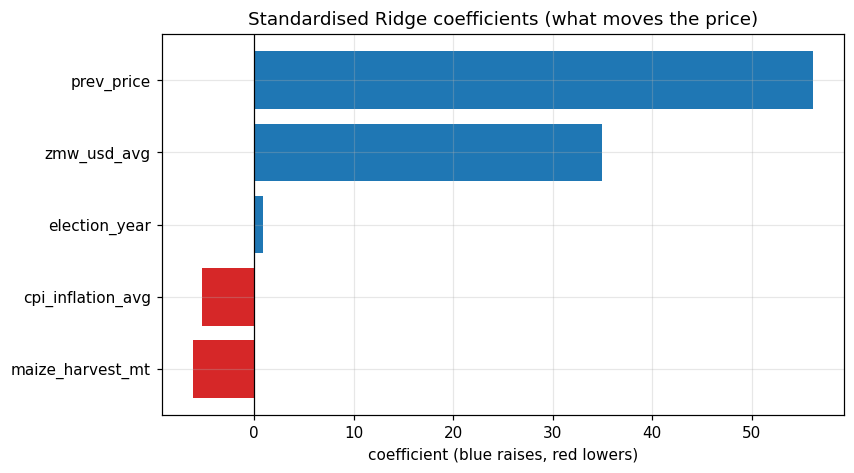

In [15]:
#  Feature influence (standardised coefficients) of the final model
sc = StandardScaler().fit(train[best_feats].values)
model = Ridge(alpha=1.0).fit(sc.transform(train[best_feats].values), y)
coefs = pd.Series(model.coef_, index=best_feats).sort_values()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(coefs.index, coefs.values,
        color=[RED if c < 0 else ACCENT for c in coefs.values])
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Standardised Ridge coefficients (what moves the price)")
ax.set_xlabel("coefficient (blue raises, red lowers)")
plt.show()

**What moves the price:**

Because the features are standardised, the bar lengths are directly comparable -
each shows a driver's effect on the price in like-for-like terms.

- **Previous year's price (~+57)** and the **exchange rate (~+35)** dominate,
  both pushing the price upward. The model is essentially *"last year's price,
  adjusted for the kwacha"* - these two factors carry almost all the weight.
- **Election year (~+1)** is negligible - a faint upward tilt, but far too small
  to rely on.
- **Harvest (~−6)** points the economically sensible way: a larger harvest nudges
  the price down. The effect is modest, confirming harvest as a minor driver.
- **Inflation (~−5)** is a small, conditional effect - once the previous price
  and the exchange rate absorb the long-run upward trend, inflation adds little
  on its own, so the sign of this weak coefficient shouldn't be over-read.

**Takeaway:** the FRA price is set by anchoring on last year and adjusting for the
kwacha. Harvest, inflation, and the election flag are genuine but minor
influences - which is why a simple, regularised model captures the picture so well.

##  Final verdict - the 2026 prediction

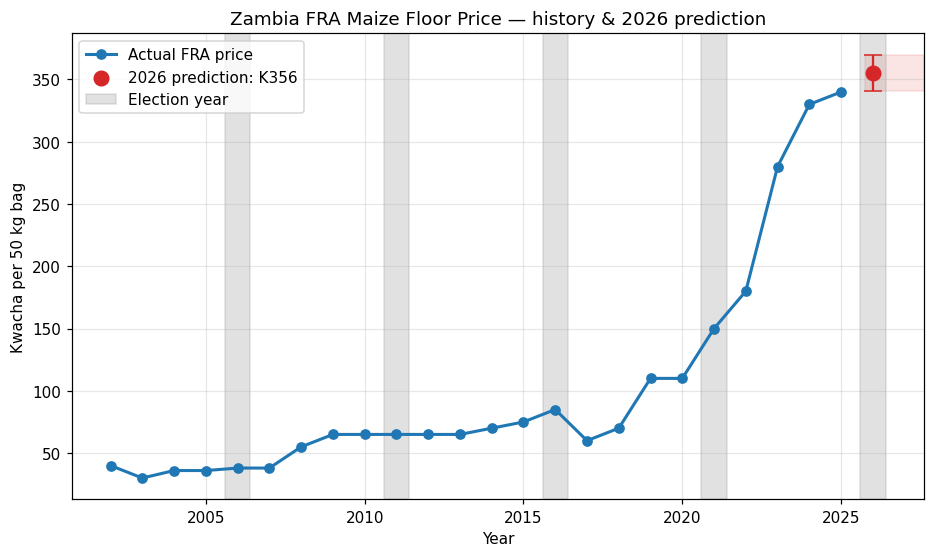

  PREDICTED 2026 FRA price: K356 per 50 kg bag
  Indicative range: K341 to K370


In [16]:
# 6. Predict 2026 and plot history + prediction with an uncertainty band
target = df[df["fra_price"].isna()].copy()
target["prev_price"] = hist["fra_price"].iloc[-1]      # = 2025 price (340)
pred = model.predict(sc.transform(target[best_feats].values))[0]
mae = mean_absolute_error(a, p)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(hist["year"], hist["fra_price"], "o-", color=ACCENT, lw=2,
        label="Actual FRA price")
ax.scatter([2026], [pred], color=RED, s=90, zorder=5,
           label=f"2026 prediction: K{pred:.0f}")
ax.errorbar([2026], [pred], yerr=mae, color=RED, capsize=6)
ax.axhspan(pred-mae, pred+mae, xmin=0.93, color=RED, alpha=0.12)

# Election-year shading 
ELECTION_SHADE = "#9e9e9e"
for i, yr in enumerate(sorted(ELECTION_YEARS)):
    ax.axvspan(yr-0.4, yr+0.4, color=ELECTION_SHADE, alpha=0.30,
               label="Election year" if i == 0 else None)

ax.set_title("Zambia FRA Maize Floor Price — history & 2026 prediction")
ax.set_xlabel("Year"); ax.set_ylabel("Kwacha per 50 kg bag")
ax.legend()
plt.show()

print("="*52)
print(f"  PREDICTED 2026 FRA price: K{pred:,.0f} per 50 kg bag")
print(f"  Indicative range: K{pred-mae:,.0f} to K{pred+mae:,.0f}")
print("="*52)

### Verdict

**Predicted 2026 FRA maize floor price: ~K356 per 50 kg bag** (indicative range
roughly K341-K371) - a modest rise on the 2025 price of K340.
This continues the FRA's steady upward path: a single-digit-percentage increase
rather than a sharp move in either direction. As an election-year announcement, a
hold or a cut would run against the historical pattern, and the model points to a
moderate rise as the most likely outcome.

**What drives this forecast:** the prediction rests mainly on two things - the
FRA's tendency to anchor on the previous year's price and adjust upward, and the
continued depreciation of the kwacha, which raises the input and financing costs
the price has to cover. Harvest size, inflation, and the election cycle play
smaller, supporting roles.

**How to read it:**

- The figure is a **directional, scenario-style forecast**, not a precise call.
  The price is ultimately set by a committee with discretion, so sudden one-off
  moves - an unexpected cut or an outsized jump - cannot be modelled.
- The estimate comes from a small annual sample (2002–2025), so the uncertainty
  band matters as much as the central figure.


**Bottom line:** the data points to a 2026 floor price in the **mid-K350s**, most
likely a single-digit-percentage increase on K340 - a continuation of the FRA's
steady upward trend.

**Caveats:**
- Small sample (~24 annual points); the high R² is partly the price's strong
  year-to-year autocorrelation, not deep model skill.
- The price is ultimately a **political decision** - presidents have overridden
  the announced figure in the past.
- **Data provenance is mixed.** The recent maize harvest figures (2017-2025) are
  from ZamStats and the FRA prices for the 2000s from an academic (MSU/FSRP)
  table - both trusted. But the five FRA-price years 2010-12 and 2014-15 harvest figures, are estimates: I could only source the verified
  series for recent years, relying on news reports for some earlier prices.